In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13240\1860997399.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [7]:
from pathlib import Path
from urllib.parse import urlparse

path = "my_paper.pdf"
parsed = urlparse(path)

if parsed.scheme in ("http", "https"):
    source = path
else:
    p = Path(path)
    if not p.is_file():
        raise FileNotFoundError(f"PDF file not found: {p.resolve()}")
    source = str(p)

loader = PyPDFLoader(source)
docs = loader.load()

In [8]:
docs

[Document(metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-09-14T02:52:38+00:00', 'author': '', 'keywords': '', 'moddate': '2021-09-14T02:52:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'subject': '', 'title': '', 'trapped': '/False', 'rgid': 'PB:357213035_AS:1103436619751424@1640091199662', 'source': 'my_paper.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='See discussions, stats, and author profiles for this publication at: https://www.researchgate.net/publication/357213035\nDevelopment of Multiple Combined Regression Methods for Rainfall\nMeasurement Development of Multiple Combined Regression Methods for\nRainfall Measurement\nArticle · December 2021\nCITATIONS\n0\nREADS\n711\n6 authors, including:\nNusrat Jahan Prottasha\nDaffodil International University\n26 PUBLICATIONS\xa0\xa0\xa0299 CITATIONS\xa0\xa0\xa0\nSEE PROFILE\nMd Kowsher\nSteven

In [9]:
len(docs)

15

In [10]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [11]:
len(chunks)

44

In [12]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store.save_local("faiss_index")

In [13]:
vector_store

In [14]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [15]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the PDF document.

    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.

    Args:
        query: The question or search query used to retrieve PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF."

    formatted_documents = []

    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )

    return "\n\n".join(formatted_documents)

In [16]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

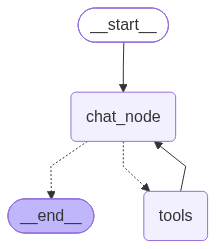

In [19]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")  
chatbot = graph.compile()

chatbot

In [20]:

# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="Hello")]})

print(result["messages"][-1].content)

Hello! I'm here to help answer your questions about the document. What would you like to know?


In [21]:
# Regular chat
result = chatbot.invoke({"messages": [HumanMessage(content="Using the pdf notes, explain about Rainfall Measurement techniques in a concise way")]})

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Based on the provided document, the focus is primarily on *predictive regression analysis techniques* and *machine learning procedures* for quantifying and forecasting rainfall, rather than detailing traditional rainfall measurement techniques.\n\nThe document mentions that there are "numerous equipment implement for foreseeing rainfall by utilizing the climate conditions like temperature, humidity, weight." However, it states that these "conventional strategies cannot work productively" and advocates for using machine learning techniques with historical data for more accurate rainfall prediction and quantification.\n\nIn essence, the document highlights a shift from conventional measurement tools to advanced analytical methods for understanding and predicting rainfall quantities.', 'extras': {'signature': 'CuIJARFNMg8TRvdXMWs/Pmbvt6uBkx5GOA/MRSp3YZNlMQRYapimyQWbFjOYbWQQnQYXXgGg/8dMU0gqG29YPRKx4MNJIU4/Linj6alXuVzuAq3fU5i8QZjLH6gpsn/VhYM0Z8AwIWy9DaAYRa7s41dOFM

In [22]:
print(result["messages"][-1].content[0]["text"])

Based on the provided document, the focus is primarily on *predictive regression analysis techniques* and *machine learning procedures* for quantifying and forecasting rainfall, rather than detailing traditional rainfall measurement techniques.

The document mentions that there are "numerous equipment implement for foreseeing rainfall by utilizing the climate conditions like temperature, humidity, weight." However, it states that these "conventional strategies cannot work productively" and advocates for using machine learning techniques with historical data for more accurate rainfall prediction and quantification.

In essence, the document highlights a shift from conventional measurement tools to advanced analytical methods for understanding and predicting rainfall quantities.
